# 2D Adhesion Notebook
Calculates adhesive energies between two flat shells for various separation distances.

In [1]:
import numpy as np
import os
import sys
import gzip
import subprocess
import importlib
import pathlib
import shutil
import yaml
import datetime
import pytz
import time
from scipy.optimize import curve_fit
cwd = os.getcwd()
itop=cwd.find("cgshells/")+len("cgshells")
PROJECT_ROOT = cwd[:itop]
sys.path.insert(0, PROJECT_ROOT )

from utils.readsim import ReadSim
# from utils.curvsim.v1.curvamer2d import Curvamer2D
# from utils.curvsim.v1.curvamer3d import Curvamer3D
import utils.run_manager as rm
# from utils.run_manager import PROJECT_ROOT, lmpunity, lmplocal
version = "v1"    # select which version of curvsim to use
curvsim = importlib.import_module(f"utils.curvsim.{version}")
Curvamer2D = rm.load_class(version, "curvamer2d", "Curvamer2D")
Curvamer3D = rm.load_class(version, "curvamer3d", "Curvamer3D")
versionpath = "/".join(curvsim.__name__.split("."))
DATASCRIPTS = f"{versionpath}/DataScripts"    # location of compatible data scripts (relative to PROJECT_ROOT)

# rm.print_header(version)
# rm.make_simpaths_file(JOBDIR,JOB)     # make empty status file for this job

import matplotlib as mpl
import matplotlib.pyplot as plt

%matplotlib inline

# def extents(result,frame=0):
#     Nbeads = int(np.max(result.dump_id[frame])/2)
#     botmask = result.dump_id[frame]<=(Nbeads)
#     topmask = result.dump_id[frame]>(Nbeads)
#     ytopavg = np.mean(result.dump_y[frame][topmask])
#     ybotavg = np.mean(result.dump_y[frame][botmask])
#     xmax = np.max(result.dump_x[frame])
#     xmin = np.min(result.dump_x[frame])
#     x = xmax-xmin
#     y = ytopavg-ybotavg
#     return (x,y)

# Run calculations

In [22]:
dcore = 1.0
##### PARTICLE #####
### Geometry
dimension = 2
dcore = 1.0    # hard core diameter of beads (dcore approx thickness of one DNA helix 3.5nm)
t0 = 1 * dcore    # structural thickness
wx = 46 * dcore # shell width (arclength along midline)
# wx = 4.9 * dcore
r0 = "flat"   # set to "flat" for particles with zero curvature
Nbeads = 130    # number of beads per layer (2Nbeads is beads per curvamer)
# Nbeads = 15
fraction = 1/3   # middle patch of beads has width = fraction * wx

sigma_list = [0.25,0.5,0.75,1.0,1.25,1.5,1.75,2.0]
# epsilon_list = (1*np.ones(len(sigma_list))).tolist()
epsilon_list = (1/np.array(emin_list)).tolist()
# epsilon_list = (10 * 1/np.array(emin_list)).tolist()

ysep_list = np.linspace((t0+dcore)*0.85,(t0+dcore)*1.2,200).tolist() 

rm.print_header(version)

jobcounter = 0
for i in range(len(sigma_list)):
    simcounter = 0
    jobcounter += 1

    print("#####################################\n")
    print(f"Setting up job {jobcounter}...")

    series_simpaths = [] # append simpaths that will run in series for each job (i.e. different ysep values)

    for j in range(len(ysep_list)):  
        
        simcounter += 1

        print(f"----Preparing simulation {simcounter}...")

        if r0 == "flat":
            k_0 = 0
        else:
            k_0 = 1/r0

        ### Elasticity
        kh = 0
        nu = 0.3
        d = wx/(Nbeads-1)   # bead spacing
        kvkh = 1 
        kckh = 1 

        ### Interactions
        pair_ints = "1patch" #"none", "repulsive", "1patch", "patchy", "attractive", or "2attractive"
        soft_ints = False
        sigma = sigma_list[i]
        epsilon = epsilon_list[i]
        shift = dcore - 2**(1/6)*sigma     # shift factor to make sure lj minimum is at dcore
        ljcut = 5*sigma #t0 + 2*dcore               # cutoff distance for attractive lj potential
        wcacut = dcore    # cutoff distance for repulsive wca potential
        softsigma = 5*sigma
        softepsilon = 5e-8 * epsilon
        softshift = 0 #softcore - 2**(1/6)*softsigma
        softcut = 2**(1/6) * softsigma

        ##### SIMULATION #####
        ysep = ysep_list[j]
        config = "stacked" #"dispersed" or "stacked"
        simtype = "emin"
        datascript = "ysep"   # script to make data file, NO .py EXTENSION, "stack", "load", or "lattice"
        orientation = "correct"    # correct binding orientation (e.g 0-1 0-1)
#         orientation = "incorrect1"    # incorrect binding orientation 1 (e.g 0-1 1-0)
#         orientation = "incorrect2"    # incorrect binding orientation 2 (e.g 1-0 0-1)
        nshells = 2
        datagz = True
        trajgz = True
        dumpbonds = False    # whether to calculate and dump bond data
        screen = False    # output lammps log to screen


        ### Stacked config settings
        k_i = 0 * k_0    # curvature of bottom shell in stack
        xlo = -2*wx
        xhi = 2*wx
        ylo = -4*t0
        yhi = 4*t0
        zlo = -0.5
        zhi = 0.5

        ### Dispersed config settings
        # phi = 0.01    # concentration of molecules (area fraction) - only for MD
        # Nx = 4    # number of particle columns for initial config (applies if simpath_old = "none")
        # Ny = int(nshells/Nx)
        # v0 = wx * (t0 + dcore)
        # lbox = np.sqrt(nshells * v0 / phi)    # side length of (square) sim box to give proper concentration
        # xlo = -lbox/2
        # xhi = lbox/2
        # ylo = -lbox/2
        # yhi = lbox/2
        # zlo = -0.5
        # zhi = 0.5

        ### Dynamics/Minimization Settings
        minstyle = "cg"
        etol = 1e-14
        maxiter = 100000

#         Tstart = 0
#         Tstop = Tstart
#         Tdamp = 1
#         seed = 15298
#         timestep = 0.0005
#         runsteps = 100000

        dumpfreq = maxiter
        thermofreq = 1000


        ##### LOGISTICS #####

        ### Simulation Directories
        delete_existing = True    # if True, deletes simulation directory if it exists before creating again
        load_simpath = False # location of trajectory file to load in (set to False if not loading in state)
        simpath = f"data/{int(dimension)}d/mesh_characteristics/wx-{wx:0.3f}-t0-{t0:0.3f}-Nbeads-{Nbeads}/interactions/{pair_ints}/sigma-{sigma:0.5f}-epsilon-{epsilon:0.5f}-soft-{soft_ints}/{orientation}/ysep-{ysep:0.3f}" # path to simulation directory (relative to PROJECT_ROOT)

        ### Computation
        computer = "local"
    #     computer = "unity"
        nnodes = 1
        mem = 1 #GB
        tlim_hrs = 0
        tlim_min = 10
        partition = "cpu-preempt"    # requested partition
        jobname = os.path.splitext(os.path.basename(sys.argv[0]))[0]
        requested_walltime = f'{tlim_hrs:02d}:{tlim_min:02d}:00'
        tbuffer = 1 # stop lammps tbuffer minutes before walltime is exceeded
                        # any non-zero value means script will auto resubmit until done
                        # zero means no auto resubmission - job stops when done or if time is exceeded
        px = 2    # number of cpus along x
        py = 1
        pz = 1
        gridfreq = 10000    # check cpu partitioning of simbox every gridfreq steps
        thresh = 1.01    # threshold imbalance to repartition simbox
        maxrestarts = 10    # max number of runs for one job (cluster only, local machine limit is set below to 5)

        # add tstep start variable?


        #################
        ##### SETUP #####
        #################

        print("--------Creating simulation directory...")

        ### Make simulation directory

        if delete_existing == True:
            if os.path.isdir(f"{PROJECT_ROOT}/{simpath}"):
                print("""----------Simulation directory already exists.
    ----------Deleting...""")
                shutil.rmtree(f"{PROJECT_ROOT}/{simpath}")
                print("----------Creating new simulation directory...")

        os.makedirs(f"{PROJECT_ROOT}/{simpath}", exist_ok=True)

#         ### Append simpaths to job status file and to series_simpaths
#         print("--------Adding simulation directory to job simpaths file...")
#         rm.update_simpaths_file(JOBDIR,JOB,simpath)
        series_simpaths.append(simpath)

        ###############################
        ##### LAMMPS INPUT SCRIPT #####
        ###############################

        print("--------Writing LAMMPS input file...")

        ### Header
        inputcontents = f"""# Coarse-grained shell model - LAMMPS input file

units lj
dimension {dimension}
boundary s s p
atom_style molecular
bond_style harmonic
angle_style none
dihedral_style none
improper_style none

processors {px} {py} {pz} grid onelevel

comm_style tiled
"""

        if datagz==True:
            inputcontents +="""
variable restart_exists equal is_file(restart.final)
if "${restart_exists}" then "read_restart restart.final" else "read_data data.lammps.gz"

"""
        else:
            inputcontents +="""
variable restart_exists equal is_file(restart.final)
if "${restart_exists}" then "read_restart restart.final" else "read_data data.lammps"

"""

        ### Interactions
        if pair_ints == "none":
            inputcontents += f"""
pair_style none
"""
        elif pair_ints == "repulsive":
            inputcontents += f"""
pair_style hybrid lj/expand {ljcut}
# upside down bonding 1
pair_coeff 1 1 lj/expand {epsilon} {sigma} {shift} {wcacut-shift}
pair_coeff 3 3 lj/expand {epsilon} {sigma} {shift} {wcacut-shift}
pair_coeff 1 3 lj/expand {epsilon} {sigma} {shift} {wcacut-shift}
# upside down bonding 2
pair_coeff 2 2 lj/expand {epsilon} {sigma} {shift} {wcacut-shift}
pair_coeff 4 4 lj/expand {epsilon} {sigma} {shift} {wcacut-shift}
pair_coeff 2 4 lj/expand {epsilon} {sigma} {shift} {wcacut-shift}
# correct bonding
pair_coeff 1 2 lj/expand {epsilon} {sigma} {shift} {wcacut-shift} # edge-edge
pair_coeff 3 4 lj/expand {epsilon} {sigma} {shift} {wcacut-shift} # center-center
pair_coeff 1 4 lj/expand {epsilon} {sigma} {shift} {wcacut-shift}
pair_coeff 2 3 lj/expand {epsilon} {sigma} {shift} {wcacut-shift}
pair_modify shift yes
\n
"""

        else:
            if soft_ints == True:
                inputcontents += f"""
pair_style hybrid lj/expand {ljcut}
# upside down bonding 1
pair_coeff 1 1 lj/expand {softepsilon} {softsigma} {softshift} {softcut-softshift}
pair_coeff 3 3 lj/expand {softepsilon} {softsigma} {softshift} {softcut-softshift}
pair_coeff 1 3 lj/expand {softepsilon} {softsigma} {softshift} {softcut-softshift}
# upside down bonding 2
pair_coeff 2 2 lj/expand {softepsilon} {softsigma} {softshift} {softcut-softshift}
pair_coeff 4 4 lj/expand {softepsilon} {softsigma} {softshift} {softcut-softshift}
pair_coeff 2 4 lj/expand {softepsilon} {softsigma} {softshift} {softcut-softshift}
"""
            else:
                inputcontents += f"""
pair_style hybrid lj/expand {ljcut}
# upside down bonding 1
pair_coeff 1 1 lj/expand {epsilon} {sigma} {shift} {wcacut-shift}
pair_coeff 3 3 lj/expand {epsilon} {sigma} {shift} {wcacut-shift}
pair_coeff 1 3 lj/expand {epsilon} {sigma} {shift} {wcacut-shift}
# upside down bonding 2
pair_coeff 2 2 lj/expand {epsilon} {sigma} {shift} {wcacut-shift}
pair_coeff 4 4 lj/expand {epsilon} {sigma} {shift} {wcacut-shift}
pair_coeff 2 4 lj/expand {epsilon} {sigma} {shift} {wcacut-shift}
"""


            if pair_ints == "1patch":
                inputcontents += f"""
# correct bonding
pair_coeff 1 2 lj/expand {epsilon} {sigma} {shift} {wcacut-shift} # edge-edge
pair_coeff 3 4 lj/expand {epsilon} {sigma} {shift} {ljcut-shift} # center-center
pair_coeff 1 4 lj/expand {epsilon} {sigma} {shift} {wcacut-shift}
pair_coeff 2 3 lj/expand {epsilon} {sigma} {shift} {wcacut-shift}
pair_modify shift yes
"""
            elif pair_ints == "patchy":
                inputcontents += f"""
# correct bonding
pair_coeff 1 2 lj/expand {epsilon} {sigma} {shift} {ljcut-shift} # edge-edge
pair_coeff 3 4 lj/expand {epsilon} {sigma} {shift} {ljcut-shift} # center-center
pair_coeff 1 4 lj/expand {epsilon} {sigma} {shift} {wcacut-shift}
pair_coeff 2 3 lj/expand {epsilon} {sigma} {shift} {wcacut-shift}
pair_modify shift yes
\n
"""

            elif pair_ints == "attractive":
                inputcontents += f"""
# correct bonding
pair_coeff 1 2 lj/expand {epsilon} {sigma} {shift} {ljcut-shift} # edge-edge
pair_coeff 3 4 lj/expand {epsilon} {sigma} {shift} {ljcut-shift} # center-center
pair_coeff 1 4 lj/expand {epsilon} {sigma} {shift} {ljcut-shift}
pair_coeff 2 3 lj/expand {epsilon} {sigma} {shift} {ljcut-shift}
pair_modify shift yes
\n
"""

        
        # Fixes
        if dimension == 2:
            inputcontents += "fix 0 all enforce2d"
        if simtype == "md":
            inputcontents += f"""
fix 1 all langevin {Tstart} {Tstop} {Tdamp} {seed}
fix 2 all nve
"""           
    #         inputcontents += f"""
    # fix 3 all rigid molecule
    # fix 4 all setforce NULL 0.0 NULL
    # fix 4 all setforce 0.0 0.0 0.0

    # group redge id {Nbeads:g} {2*Nbeads:g}
    # fix 5 redge setforce {force:f} 0.0 0.0
    # fix 5 redge addforce {force:f} 0.0 0.0
    # group ledge id {1:g} {Nbeads+1:g}
    # fix 6 ledge setforce {-force:f} 0.0 0.0
    # fix 6 ledge addforce {force:f} 0.0 0.0"""

#             inputcontents += f"""
# group redge id {Nbeads:g} {2*Nbeads:g}
# fix 5 redge addforce {force:f} 0.0 0.0
# group ledge id {1:g} {Nbeads+1:g}
# fix 6 ledge addforce -{force:f} 0.0 0.0
# """

        if simtype == "emin":
            inputcontents += f"""
fix 4 all setforce 0.0 0.0 0.0
"""

        inputcontents += f"""
fix 7 all balance {gridfreq} {thresh} rcb

neigh_modify exclude molecule/intra all every 5 delay 0 check yes
# special_bonds lj 0.0 0.0 0.0

thermo_style custom step etotal ke pe epair ebond temp press
thermo {thermofreq}
thermo_modify norm no
"""
        
        if dumpbonds == True:
            inputcontents += f"""
compute btype all property/local btype
compute batom1 all property/local batom1
compute batom2 all property/local batom2
compute bdist all bond/local dist
compute bpot all bond/local engpot
dump 2 all local {dumpfreq} bonds.dump.gz index c_btype c_batom1 c_batom2 c_bdist c_bpot
"""
    #     fdata.write("\ndump 1 all custom {} {}/trajectory.dump mol id type x y z".format(dumpfreq,simpath))

        if trajgz==True:
            inputcontents += f"""
dump 1 all custom/gz {dumpfreq} trajectory${{stage}}.dump.gz mol id type x y z
dump_modify 1 append no sort id
"""
        else:
            inputcontents += f"""
dump 1 all custom {dumpfreq} trajectory${{stage}}.dump mol id type x y z
dump_modify 1 append no sort id
"""

        if simtype == "md":
            inputcontents += f"""
timer timeout {int(tlim_hrs*3600 + tlim_min*60 - tbuffer*60)}
timestep {timestep}
run {runsteps} upto
write_restart restart.final
"""
        elif simtype == "emin":
            inputcontents += f"""
timer timeout {int(tlim_hrs*3600 + tlim_min*60 - tbuffer*60)}
min_style {minstyle}
minimize {etol} 0.0 {maxiter} {10*maxiter}
write_restart restart.final
"""        

        # Write LAMMPS input file
        with open(f"{PROJECT_ROOT}/{simpath}/in.lammps", "w") as f:
            f.write(inputcontents)



        ###############################
        ##### WRITE METADATA FILE #####
        ###############################

        print("--------Writing metadata file...")

        params = {

            'particle':{
                'geometry':{
                    'dimension':dimension,
                    'dcore':dcore,
                    't0':t0,
                    'wx':wx,
                    'r0':r0,
                    'Nbeads':Nbeads,
                    'fraction':fraction
                },
                'elasticity':{
                    'nu':nu,
                    'kh':kh,
                    'kckh':kckh,
                    'kvkh':kvkh
                },
                'interactions':{
                    'pair_ints':pair_ints,
                    'soft_ints':int(soft_ints),
                    'sigma':sigma,
                    'epsilon':epsilon,
                    'shift':shift,
                    'ljcut':ljcut,
                    'wcacut':wcacut,

                },
            },

            'simulation':{
                'simtype':simtype,
                'config':config,
                'nshells':nshells,
                'datascript':datascript,
                'xlo':float(xlo),
                'xhi':float(xhi),
                'ylo':float(ylo),
                'yhi':float(yhi),
                'zlo':float(zlo),
                'zhi':float(zhi),
                'simbox_x':float(xhi-xlo),
                'simbox_y':float(yhi-ylo),
                'simbox_z':float(zhi-zlo),
                'thermofreq':thermofreq,
                'dumpfreq':dumpfreq,
                'datagz':datagz,
                'trajgz':trajgz,
                'dumpbonds':dumpbonds


            },

            'logistics':{
                'computer':computer,
                'jobname':jobname,
                'simpath':simpath,
                'tbuffer':tbuffer,
                'run_counter':0

            }
        }

        if soft_ints == True:
            softparams = {'softsigma':softsigma,'softepsilon':softepsilon,
                    'softshift':softshift,'softcut':softcut}
            params['particle']['interactions'].update(softparams)

        if simtype == "emin":
            eminparams = {'minstyle':minstyle,'etol':etol,'maxiter':maxiter}
            params['simulation'].update(eminparams)

        if simtype == "md":
            mdparams = {'Tstart':Tstart,'Tstop':Tstop,'Tdamp':Tdamp,'seed':seed,
                        'timestep':timestep,'runsteps':runsteps}
            params['simulation'].update(mdparams)

        if config == "dispersed":
            disp_params = {'phi':phi}
            params['simulation'].update(disp_params)

        if config == "stacked":
            stack_params = {'k_i':k_i,'orientation':orientation,'ysep':ysep}
            params['simulation'].update(stack_params)

        if computer != 'local':
            clusterparams = {'nnodes':nnodes,'cpus':px*py*pz,'mem':mem,
                             'partition':partition,'requested_walltime':requested_walltime}
            params['logistics'].update(clusterparams)

        if load_simpath == False:
            loadparams = {'load_simpath':int(load_simpath)}
        else:
            loadparams = {'load_simpath':load_simpath}
        params['logistics'].update(loadparams)


        # Write YAML metadata
        rm.write_metadata(f"{PROJECT_ROOT}/{simpath}",params)


        print(f"----Simulation {simcounter} prepared.")

        ################################
        ##### RUN ON LOCAL MACHINE #####
        ################################

        if computer == "local":
            nrestarts = 1
            maxrestarts = 5    # max number of runs to try to finish job
            restartjob = True
            while (restartjob==True) and (nrestarts<=maxrestarts):
                print(f"Running job {jobcounter} sim {simcounter}.{nrestarts} on local machine...")

                meta = rm.read_metadata(f"{PROJECT_ROOT}/{simpath}")
                # on first run create data file
                if meta['logistics']['run_counter'] == 0:
                    make_data = rm.load_class('DataScripts',f'{datascript}','make_data',base_module=f"utils.curvsim.{version}")
                    t1 = time.time()
                    make_data(simpath)
                    t2 = time.time()
                    rm.update_metadata(f"{PROJECT_ROOT}/{simpath}",increment_run=True,sub='logistics',params={'datatime':t2-t1})
                    print(f"Time to create data file: {rm.convert_time(t2-t1)}")

                print("Updating metadata with start time...")
                rm.update_metadata(f"{PROJECT_ROOT}/{simpath}",start_times=True)
                print("Executing LAMMPS...")
                ncpus = px*py*pz
                meta = rm.read_metadata(f"{PROJECT_ROOT}/{simpath}")    # check what stage to use
                rm.run_lmp(simpath,computer,ncpus,screen,stage = meta['logistics']['run_counter'])
                print("Updating metadata with run info ...")
                rm.update_metadata(f"{PROJECT_ROOT}/{simpath}",walltimes=True,steps=True,energies=True)
                if simtype == "emin":
                    result = ReadSim(f"{PROJECT_ROOT}/{simpath}")
                    result.read_log()
                    rm.update_metadata(f"{PROJECT_ROOT}/{simpath}",sub="logistics",params = {'stopcriterion':result.why_stop})
                # NEED MD SECTION HERE
                restartjob = rm.check_restart(f"{PROJECT_ROOT}/{simpath}")
                if restartjob:
                    print("Reached walltime limit.  Restarting new run...")
                    nrestarts += 1
                    if nrestarts <= maxrestarts:
                        rm.update_metadata(f"{PROJECT_ROOT}/{simpath}",increment_run=True)
                print("\n#####################################")

            if nrestarts > maxrestarts:
                print(f"Max number of restarts exceeded ({maxrestarts}).")
                print("#####################################")


######################################
######################################

    Coarse-Grained Shell Simulator   
    
        Kyle Thomas Sullivan
       kyltsullivan@umass.edu
       
######################################
######################################

Using curvsim v1

######################################
#####################################

Setting up job 1...
----Preparing simulation 1...
--------Creating simulation directory...
----------Simulation directory already exists.
    ----------Deleting...
----------Creating new simulation directory...
--------Writing LAMMPS input file...
--------Writing metadata file...
----Simulation 1 prepared.
Running job 1 sim 1.1 on local machine...
Using ysep.py to create data file...
nshells = 2
...preparing new simulation data
...making data file
Time to create data file: 0d - 0hrs 0min 0.012811899185180664sec
Updating metadata with start time...
Executing LAMMPS...
LAMMPS Runtime: 0.0hrs 0.0min 0.2sec
Updating metadata with r

LAMMPS Runtime: 0.0hrs 0.0min 0.1sec
Updating metadata with run info ...

#####################################
----Preparing simulation 14...
--------Creating simulation directory...
----------Simulation directory already exists.
    ----------Deleting...
----------Creating new simulation directory...
--------Writing LAMMPS input file...
--------Writing metadata file...
----Simulation 14 prepared.
Running job 1 sim 14.1 on local machine...
Using ysep.py to create data file...
nshells = 2
...preparing new simulation data
...making data file
Time to create data file: 0d - 0hrs 0min 0.010485172271728516sec
Updating metadata with start time...
Executing LAMMPS...
LAMMPS Runtime: 0.0hrs 0.0min 0.1sec
Updating metadata with run info ...

#####################################
----Preparing simulation 15...
--------Creating simulation directory...
----------Simulation directory already exists.
    ----------Deleting...
----------Creating new simulation directory...
--------Writing LAMMPS inpu

LAMMPS Runtime: 0.0hrs 0.0min 0.1sec
Updating metadata with run info ...

#####################################
----Preparing simulation 28...
--------Creating simulation directory...
----------Simulation directory already exists.
    ----------Deleting...
----------Creating new simulation directory...
--------Writing LAMMPS input file...
--------Writing metadata file...
----Simulation 28 prepared.
Running job 1 sim 28.1 on local machine...
Using ysep.py to create data file...
nshells = 2
...preparing new simulation data
...making data file
Time to create data file: 0d - 0hrs 0min 0.011443853378295898sec
Updating metadata with start time...
Executing LAMMPS...
LAMMPS Runtime: 0.0hrs 0.0min 0.1sec
Updating metadata with run info ...

#####################################
----Preparing simulation 29...
--------Creating simulation directory...
----------Simulation directory already exists.
    ----------Deleting...
----------Creating new simulation directory...
--------Writing LAMMPS inpu

LAMMPS Runtime: 0.0hrs 0.0min 0.1sec
Updating metadata with run info ...

#####################################
----Preparing simulation 42...
--------Creating simulation directory...
----------Simulation directory already exists.
    ----------Deleting...
----------Creating new simulation directory...
--------Writing LAMMPS input file...
--------Writing metadata file...
----Simulation 42 prepared.
Running job 1 sim 42.1 on local machine...
Using ysep.py to create data file...
nshells = 2
...preparing new simulation data
...making data file
Time to create data file: 0d - 0hrs 0min 0.010686159133911133sec
Updating metadata with start time...
Executing LAMMPS...
LAMMPS Runtime: 0.0hrs 0.0min 0.1sec
Updating metadata with run info ...

#####################################
----Preparing simulation 43...
--------Creating simulation directory...
----------Simulation directory already exists.
    ----------Deleting...
----------Creating new simulation directory...
--------Writing LAMMPS inpu

LAMMPS Runtime: 0.0hrs 0.0min 0.1sec
Updating metadata with run info ...

#####################################
----Preparing simulation 56...
--------Creating simulation directory...
----------Simulation directory already exists.
    ----------Deleting...
----------Creating new simulation directory...
--------Writing LAMMPS input file...
--------Writing metadata file...
----Simulation 56 prepared.
Running job 1 sim 56.1 on local machine...
Using ysep.py to create data file...
nshells = 2
...preparing new simulation data
...making data file
Time to create data file: 0d - 0hrs 0min 0.011097192764282227sec
Updating metadata with start time...
Executing LAMMPS...
LAMMPS Runtime: 0.0hrs 0.0min 0.1sec
Updating metadata with run info ...

#####################################
----Preparing simulation 57...
--------Creating simulation directory...
----------Simulation directory already exists.
    ----------Deleting...
----------Creating new simulation directory...
--------Writing LAMMPS inpu

...

LAMMPS Runtime: 0.0hrs 0.0min 0.1sec
Updating metadata with run info ...

#####################################
----Preparing simulation 127...
--------Creating simulation directory...
--------Writing LAMMPS input file...
--------Writing metadata file...
----Simulation 127 prepared.
Running job 8 sim 127.1 on local machine...
Using ysep.py to create data file...
nshells = 2
...preparing new simulation data
...making data file
Time to create data file: 0d - 0hrs 0min 0.010814905166625977sec
Updating metadata with start time...
Executing LAMMPS...
LAMMPS Runtime: 0.0hrs 0.0min 0.1sec
Updating metadata with run info ...

#####################################
----Preparing simulation 128...
--------Creating simulation directory...
--------Writing LAMMPS input file...
--------Writing metadata file...
----Simulation 128 prepared.
Running job 8 sim 128.1 on local machine...
Using ysep.py to create data file...
nshells = 2
...preparing new simulation data
...making data file
Time to create dat

LAMMPS Runtime: 0.0hrs 0.0min 0.1sec
Updating metadata with run info ...

#####################################
----Preparing simulation 143...
--------Creating simulation directory...
--------Writing LAMMPS input file...
--------Writing metadata file...
----Simulation 143 prepared.
Running job 8 sim 143.1 on local machine...
Using ysep.py to create data file...
nshells = 2
...preparing new simulation data
...making data file
Time to create data file: 0d - 0hrs 0min 0.010486841201782227sec
Updating metadata with start time...
Executing LAMMPS...
LAMMPS Runtime: 0.0hrs 0.0min 0.1sec
Updating metadata with run info ...

#####################################
----Preparing simulation 144...
--------Creating simulation directory...
--------Writing LAMMPS input file...
--------Writing metadata file...
----Simulation 144 prepared.
Running job 8 sim 144.1 on local machine...
Using ysep.py to create data file...
nshells = 2
...preparing new simulation data
...making data file
Time to create dat

LAMMPS Runtime: 0.0hrs 0.0min 0.1sec
Updating metadata with run info ...

#####################################
----Preparing simulation 159...
--------Creating simulation directory...
--------Writing LAMMPS input file...
--------Writing metadata file...
----Simulation 159 prepared.
Running job 8 sim 159.1 on local machine...
Using ysep.py to create data file...
nshells = 2
...preparing new simulation data
...making data file
Time to create data file: 0d - 0hrs 0min 0.010711193084716797sec
Updating metadata with start time...
Executing LAMMPS...
LAMMPS Runtime: 0.0hrs 0.0min 0.1sec
Updating metadata with run info ...

#####################################
----Preparing simulation 160...
--------Creating simulation directory...
--------Writing LAMMPS input file...
--------Writing metadata file...
----Simulation 160 prepared.
Running job 8 sim 160.1 on local machine...
Using ysep.py to create data file...
nshells = 2
...preparing new simulation data
...making data file
Time to create dat

LAMMPS Runtime: 0.0hrs 0.0min 0.1sec
Updating metadata with run info ...

#####################################
----Preparing simulation 175...
--------Creating simulation directory...
--------Writing LAMMPS input file...
--------Writing metadata file...
----Simulation 175 prepared.
Running job 8 sim 175.1 on local machine...
Using ysep.py to create data file...
nshells = 2
...preparing new simulation data
...making data file
Time to create data file: 0d - 0hrs 0min 0.010900020599365234sec
Updating metadata with start time...
Executing LAMMPS...
LAMMPS Runtime: 0.0hrs 0.0min 0.1sec
Updating metadata with run info ...

#####################################
----Preparing simulation 176...
--------Creating simulation directory...
--------Writing LAMMPS input file...
--------Writing metadata file...
----Simulation 176 prepared.
Running job 8 sim 176.1 on local machine...
Using ysep.py to create data file...
nshells = 2
...preparing new simulation data
...making data file
Time to create dat

LAMMPS Runtime: 0.0hrs 0.0min 0.1sec
Updating metadata with run info ...

#####################################
----Preparing simulation 191...
--------Creating simulation directory...
--------Writing LAMMPS input file...
--------Writing metadata file...
----Simulation 191 prepared.
Running job 8 sim 191.1 on local machine...
Using ysep.py to create data file...
nshells = 2
...preparing new simulation data
...making data file
Time to create data file: 0d - 0hrs 0min 0.010713815689086914sec
Updating metadata with start time...
Executing LAMMPS...
LAMMPS Runtime: 0.0hrs 0.0min 0.1sec
Updating metadata with run info ...

#####################################
----Preparing simulation 192...
--------Creating simulation directory...
--------Writing LAMMPS input file...
--------Writing metadata file...
----Simulation 192 prepared.
Running job 8 sim 192.1 on local machine...
Using ysep.py to create data file...
nshells = 2
...preparing new simulation data
...making data file
Time to create dat

## Read sims and plot

In [23]:
##### PARTICLE #####
### Geometry
dimension = 2
dcore = 1.0    # hard core diameter of beads (dcore approx thickness of one DNA helix 3.5nm)
t0 = 1.0 * dcore    # structural thickness
# wx = 46 * dcore    # shell width (arclength along midline)
wx = 4.9 * dcore
# r0 = "flat"   # set to "flat" for particles with zero curvature
# Nbeads = 130    # number of beads per layer (2Nbeads is beads per curvamer)
Nbeads = 15
fraction = 1/3    # middle patch of beads has width = fraction * wx
pair_ints = "1patch" #"none", "repulsive", "1patch", "patchy", "attractive", or "2attractive"
soft_ints = False

# sigma_list = [1.0]  
# epsilon_list = #[0.0044]
orientation = "correct"
# orientation = "incorrect1"
# orientation = "incorrect2"
ysep_list = "all"   # plot all ysep simulations found in mesh directory
# ysep_list = np.linspace((t0+dcore)*0.8,(t0+dcore)*1.2,100).tolist()   # only plot these ysep values

sigmas = []
yseps = []
eadhs = []
jobcounter = 0
for i in range(len(sigma_list)):   
    sigma = sigma_list[i]
    epsilon = epsilon_list[i]
    parentsimpath = f"data/{int(dimension)}d/mesh_characteristics/wx-{wx:0.3f}-t0-{t0:0.3f}-Nbeads-{Nbeads}/interactions/{pair_ints}/sigma-{sigma:0.5f}-epsilon-{epsilon:0.5f}-soft-{soft_ints}/{orientation}"
    series_simpaths = [] # append simpaths for plotting (i.e. different kh values)
    
    if ysep_list == "all":
        yseplist = []
        files = os.listdir(f"{PROJECT_ROOT}/{parentsimpath}")
        for f in files:
            ysep = float(f[5:])
            yseplist.append(ysep)
            series_simpaths.append(f"{parentsimpath}/{f}")
    
    else:
        yseplist = ysep_list
        for j in range(len(ysep_list)):  
            ysep  = ysep_list[j]
            simpath = f"{parentsimpath}/ysep-{ysep:0.3f}" # path to simulation directory (relative to PROJECT_ROOT)
            series_simpaths.append(simpath)
    
    sigmalist = []
    eadhlist = []
    for s in series_simpaths:
        logname = "log.lammps"
        result = ReadSim(f"{PROJECT_ROOT}/{s}")
        result.read_log(logname=logname)
        eadh = result.energyf
        eadhlist.append(eadh)
        sigmalist.append(sigma)
    eadhs.append(eadhlist)
    sigmas.append(sigmalist)
    yseps.append(yseplist)
    

sigma_list = np.array([0.25, 0.5, 0.75, 1.0, 1.25, 1.5, 1.75, 2.0])
epsilon_list = np.array([0.012295662927237464, 0.007454425251112783, 0.005928563181698954, 0.00500918061860273, 0.004362265760618837, 0.0038676271138658176, 0.0034696166812905995, 0.003139490388929374])
emin_list = np.array([1.0, 0.999999999999995, 0.999999999999999, 1.0, 0.999999999999998, 0.999999999999997, 0.999999999999999, 1.0])
tmin_list = np.array([1.995, 1.988, 1.978, 1.967, 1.96, 1.95, 1.939, 1.929])


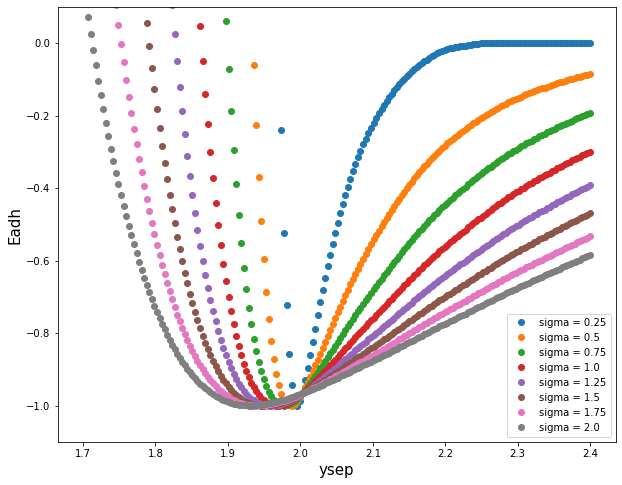

In [24]:

fig, ax = plt.subplots(1,1,figsize=(10,8))
for i in range(len(sigmas)):
    ax.plot(np.array(yseps[i]),np.array(eadhs[i]),"o",label=f"sigma = {sigmas[i][0]}")
# ax.set_xlim(1.4,2)
# ax.set_ylim(-100,10)
# ax.set_ylim(-0.25,10)
# ax.set_ylim(-50,0.5)


# ax.set_xlim(2,3)
ax.set_ylim(-1.1,0.1)
ax.legend()
ax.set_xlabel("ysep",fontsize=15)
ax.set_ylabel("Eadh",fontsize=15)

emin_list = []
tmin_list = []
for i in range(len(eadhs)):
    imin = np.argmin(eadhs[i])
    emin = np.abs(eadhs[i][imin])
    tmin = np.abs(yseps[i][imin])
    emin_list.append(emin)
    tmin_list.append(tmin)
print(f"sigma_list = np.array({sigma_list})")
print(f"epsilon_list = np.array({epsilon_list})")
print(f"emin_list = np.array({emin_list})")
print(f"tmin_list = np.array({tmin_list})")

sigma_list = np.array([0.25, 0.5, 0.75, 1.0, 1.25, 1.5, 1.75, 2.0])
alist = np.array([954.0485445065802, 169.96267674786702, 73.86236147841257, 40.50335526742512, 24.82595080435218, 17.846621440821153, 13.262362838626839, 10.130182221190214])
tmin_list = np.array([1.995, 1.988, 1.978, 1.967, 1.96, 1.95, 1.939, 1.929])
x0list = np.array([1.9968065472282508, 1.98981537644663, 1.981550539798314, 1.9738800556660248, 1.9661164322121458, 1.9590548861153703, 1.95101069856075, 1.9434194045339475])
emin_list = np.array([1.0, 0.999999999999995, 0.999999999999999, 1.0, 0.999999999999998, 0.999999999999997, 0.999999999999999, 1.0])
y0list = np.array([-1.0034160205900322, -1.000577332790157, -1.0012060919071821, -1.0022997345145577, -1.0019560767424365, -1.0028656858725327, -1.0027159451505814, -1.0025170924621933])
epsilon_list = np.array([0.012295662927237464, 0.007454425251112783, 0.005928563181698954, 0.00500918061860273, 0.004362265760618837, 0.0038676271138658176, 0.0034696166812905995, 0.003

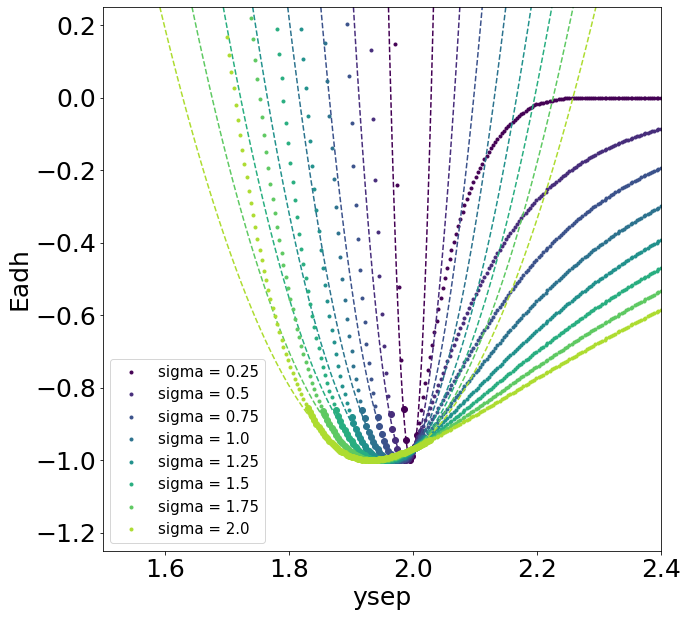

In [71]:
def harmonicfit(x,a,x0,y0):
    return a*(x-x0)**2 + y0
alist = []
x0list = []
y0list = []

cmap = plt.cm.viridis

fig, ax = plt.subplots(1,1,figsize=(10,10))
for i in range(len(sigma_list)):
    mask = (np.array(yseps[i])-tmin_list[i])**2 <= (0.05*sigma_list[i])**2
    ax.plot(np.array(yseps[i])[mask],np.array(eadhs[i])[mask],"o",color = cmap(i/(len(sigma_list))))
    ax.plot(np.array(yseps[i]),np.array(eadhs[i]),".",label=f"sigma = {sigma_list[i]}", color = cmap(i/(len(sigma_list))))
    xdata = np.array(yseps[i])[mask]
    ydata = np.array(eadhs[i])[mask]
    params, err = curve_fit(harmonicfit,xdata,ydata,p0=np.array([1,tmin_list[i],-emin_list[i]]))
    (abest,x0best,y0best)=params
    alist.append(abest)
    x0list.append(x0best)
    y0list.append(y0best)
    xfit = np.linspace(tmin_list[i]-0.2*sigma_list[i],tmin_list[i]+0.2*sigma_list[i],100)
    ax.plot(xfit,harmonicfit(xfit,abest,x0best,y0best),"--",color = cmap(i/(len(sigma_list))))
    
ax.set_xlim(1.5,2.4)
# ax.set_ylim(-200,10)
ax.set_ylim(-1.25,0.25)
ax.legend(fontsize=15)
ax.set_xlabel("ysep",fontsize=25)
ax.set_ylabel("Eadh",fontsize=25)
ax.tick_params(labelsize=25)

print(f"sigma_list = np.array({sigma_list})")
print(f"alist = np.array({alist})")
print(f"tmin_list = np.array({tmin_list})")
print(f"x0list = np.array({x0list})")
print(f"emin_list = np.array({emin_list})")
print(f"y0list = np.array({y0list})")
print(f"epsilon_list = np.array({epsilon_list})")

In [72]:
sigmaeff_list = np.sqrt(2*np.abs(np.array(y0list))/np.array(alist))
sigmaeff_list*4.35

array([0.19950764, 0.47201174, 0.71623312, 0.96773748, 1.23587814,
       1.45830255, 1.69154191, 1.9352698 ])

In [59]:
50*4.35

217.49999999999997

In [63]:
wx/(2*np.pi*50)

0.1464225476445437

In [50]:
i = 1
j = len(sigma_list) #i+1
print(f"sigma = {sigma_list[i:j]}")
print(f"epsilon = {epsilon_list[i:j]}")

sigma = [0.5, 0.75, 1.0, 1.25, 1.5, 1.75, 2.0]
epsilon = [0.007454425251112783, 0.005928563181698954, 0.00500918061860273, 0.004362265760618837, 0.0038676271138658176, 0.0034696166812905995, 0.003139490388929374]


In [76]:
i = 4
print(sigma_list[i])
print(epsilon_list[i])


1.25
0.004362265760618837


In [127]:
int(8/2 )

4

In [49]:
sigma_list = np.array([0.5, 1.0, 2.0])
epsilon_list = np.array([0.019506678275248088, 0.012528227269138303, 0.007709308853874567])
emin_list = np.array([0.999999999999998, 1.0, 1.0])
tmin_list = np.array([1.996, 1.98, 1.939])


[1.996, 1.98, 1.939]

In [112]:
emin_list

[152.046577901046, 227.161307304226, 364.63925065489]

In [89]:
plt.cm.viridis(1)

(0.26851, 0.009605, 0.335427, 1.0)

In [54]:
tmin_list[i]

1.996

sigma_list = np.array([1.0, 1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9, 2.0])
alist = np.array([36.15725452489518, 31.968873381668395, 25.096303282010112, 23.612367691339976, 18.739736303507065, 17.842230174849202, 14.560571959360132, 13.881919359908588, 11.741535235842987, 10.95092209514363, 10.286342355374774])
tmin_list = np.array([1.972, 1.964, 1.964, 1.956, 1.956, 1.947, 1.947, 1.939, 1.939, 1.931, 1.923])
x0list = np.array([1.9739366185999592, 1.969368214174369, 1.9670601382542228, 1.9643382788460393, 1.9604277388751765, 1.9577024347672978, 1.953855740753136, 1.9510345908428168, 1.949086879608408, 1.944153926294684, 1.9408158757601384])
emin_list = np.array([1.0, 0.999999999999994, 1.0, 1.0, 1.0, 0.999999999999999, 0.999999999999992, 0.999999999999996, 1.0, 0.999999999999995, 1.0])
y0list = np.array([-1.0004528949845974, -1.0016737015366268, -1.0011333054377727, -1.0035117221901855, -1.00174311528133, -1.0036445523907263, -1.0020060327540088, -1.0033888002625906, -1.002587847428

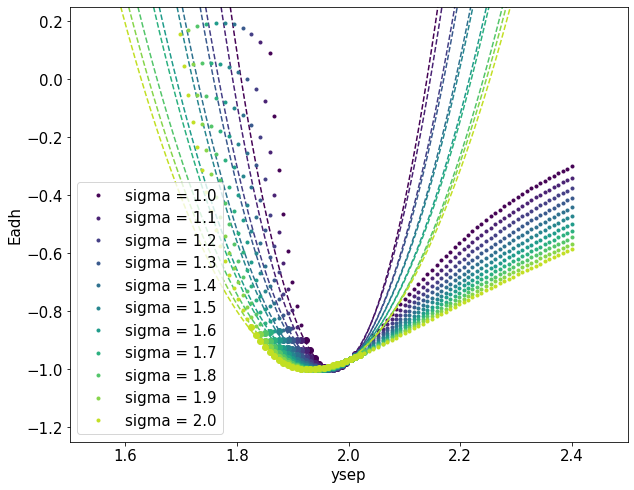

In [148]:
def harmonicfit(x,a,x0,y0):
    return a*(x-x0)**2 + y0
alist = []
x0list = []
y0list = []

cmap = plt.cm.viridis

fig, ax = plt.subplots(1,1,figsize=(10,8))
for i in range(len(sigma_list)):
    mask = (np.array(yseps[i])-tmin_list[i])**2 <= (0.05*sigma_list[i])**2
    ax.plot(np.array(yseps[i])[mask],np.array(eadhs[i])[mask],"o",color = cmap(i/(len(sigma_list))))
    ax.plot(np.array(yseps[i]),np.array(eadhs[i]),".",label=f"sigma = {sigma_list[i]}", color = cmap(i/(len(sigma_list))))
    xdata = np.array(yseps[i])[mask]
    ydata = np.array(eadhs[i])[mask]
    params, err = curve_fit(harmonicfit,xdata,ydata,p0=np.array([1,tmin_list[i],-emin_list[i]]))
    (abest,x0best,y0best)=params
    alist.append(abest)
    x0list.append(x0best)
    y0list.append(y0best)
    xfit = np.linspace(tmin_list[i]-0.2*sigma_list[i],tmin_list[i]+0.2*sigma_list[i],100)
    ax.plot(xfit,harmonicfit(xfit,abest,x0best,y0best),"--",color = cmap(i/(len(sigma_list))))
    
ax.set_xlim(1.5,2.5)
# ax.set_ylim(-200,10)
ax.set_ylim(-1.25,0.25)
ax.legend(fontsize=15)
ax.set_xlabel("ysep",fontsize=15)
ax.set_ylabel("Eadh",fontsize=15)
ax.tick_params(labelsize=15)

print(f"sigma_list = np.array({sigma_list})")
print(f"alist = np.array({alist})")
print(f"tmin_list = np.array({tmin_list})")
print(f"x0list = np.array({x0list})")
print(f"emin_list = np.array({emin_list})")
print(f"y0list = np.array({y0list})")
print(f"epsilon_list = np.array({epsilon_list})")